In [25]:
import sys
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import torch
from sklearn.manifold import TSNE
from tqdm.notebook import tqdm

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.data.data_loader import get_graph
from src.generation.graph_generator import generate_matching_graph
from src.embeddings.graph_embeddings import get_embeddings

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)
torch.manual_seed(42)

In [19]:
DATASETS = ['facebook', 'arxiv', 'lastfm', 'twitch_ru']
MODELS = ['er', 'ws', 'ba', 'bter']

# Для хранения результатов
ALL_RESULTS = []

In [20]:
def mmd_rbf(X, Y, gamma=1.0):
    """Maximum Mean Discrepancy с RBF ядром."""
    XX = np.dot(X, X.T)
    YY = np.dot(Y, Y.T)
    XY = np.dot(X, Y.T)
    
    K_XX = np.exp(-gamma * (np.diag(XX)[:, None] + np.diag(XX)[None, :] - 2*XX))
    K_YY = np.exp(-gamma * (np.diag(YY)[:, None] + np.diag(YY)[None, :] - 2*YY))
    K_XY = np.exp(-gamma * (np.diag(XX)[:, None] + np.diag(YY)[None, :] - 2*XY))
    
    return K_XX.mean() + K_YY.mean() - 2 * K_XY.mean()

In [21]:
def get_graphsage_embeddings(G, model, max_deg, device='cpu'):
    """Применяет ОБУЧЕННУЮ модель GraphSAGE к новому графу."""
    if G.is_directed():
        G = G.to_undirected()
    
    nodes = list(G.nodes())
    n_nodes = len(nodes)
    
    adj = nx.to_numpy_array(G)
    adj = torch.FloatTensor(adj).to(device)
    
    degrees = np.array([min(G.degree(n), max_deg) for n in nodes])
    features = np.zeros((n_nodes, max_deg + 1))
    features[np.arange(n_nodes), degrees] = 1.0
    features = torch.FloatTensor(features).to(device)
    
    model.eval()
    with torch.no_grad():
        embeddings = model(features, adj).cpu().numpy()
    
    return embeddings

In [23]:
from tqdm.notebook import tqdm

for dataset_name in tqdm(DATASETS, desc="Датасеты"):
    print(f"\n{'='*60}")
    print(f"ОБРАБОТКА {dataset_name.upper()}")
    print('='*60)
    
    # 1. Загрузка реального графа
    G_real = get_graph(dataset_name)
    print(f"Реальный граф: {G_real.number_of_nodes()} вершин, {G_real.number_of_edges()} рёбер")
    
    # 2. Генерация синтетики
    G_synth = {}
    for model_name in MODELS:
        G_synth[model_name] = generate_matching_graph(
            G_real, 
            model=model_name, 
            base_graph_name=dataset_name, 
            seed=42
        )
    print(f"Синтетические графы сгенерированы")
    
    # 3. Удаляем старый кэш эмбеддингов (чтобы модель точно обучилась)
    cache_path = PROJECT_ROOT / "data" / "processed" / "embeddings" / f"{dataset_name}_graphsage_d32_h64-32_embeddings.pkl"
    if cache_path.exists():
        os.remove(cache_path)
        print("Старый кэш эмбеддингов удалён")
    
    # 4. Обучение GraphSAGE на реальном графе
    print("Обучение GraphSAGE...")
    _, emb_matrix_real, model = get_embeddings(
        G_real,
        graph_name=dataset_name,
        method="graphsage",
        dimensions=32,
        hidden_dims=[64, 32],
        epochs=100,
        lr=0.01,
        seed=42
    )
    max_deg = model.max_deg
    print(f"Эмбеддинги реального графа: {emb_matrix_real.shape}, max_deg={max_deg}")
    
    # 5. Извлечение эмбеддингов для синтетики
    emb_synth = {}
    for model_name in MODELS:
        emb_synth[model_name] = get_graphsage_embeddings(
            G_synth[model_name], 
            model, 
            max_deg=max_deg
        )
    
    # 6. Вычисление MMD
    print("\nMMD между реальным графом и синтетическими:")
    for model_name in MODELS:
        mmd = mmd_rbf(emb_matrix_real, emb_synth[model_name])
        print(f"  {model_name.upper()}: {mmd:.6f}")
        ALL_RESULTS.append({
            'dataset': dataset_name,
            'model': model_name.upper(),
            'mmd': mmd,
            'nodes': G_real.number_of_nodes(),
            'edges': G_real.number_of_edges()
        })

Датасеты:   0%|          | 0/4 [00:00<?, ?it/s]


ОБРАБОТКА FACEBOOK
📂 Загрузка готового графа из facebook_graph.pkl
Реальный граф: 4039 вершин, 88234 рёбер
📂 Загружен кешированный ER граф: er_base_graphfacebook_directedFalse_mNone_n4039_p0p010819963503439287_seed42.pkl
📂 Загружен кешированный WS граф: ws_base_graphfacebook_k44_n4039_p0p1_seed42.pkl
📂 Загружен кешированный BA граф: ba_base_graphfacebook_m21_n4039_seed42.pkl
📂 Загружен кешированный BTER граф: bter_base_graphfacebook_clustering0p6055467186200862_n4039_seed42.pkl
Синтетические графы сгенерированы
Обучение GraphSAGE...
🚀 Обучение GraphSAGE: 100 эпох
  Epoch 10/100, Loss: 1.0101
  Epoch 20/100, Loss: 0.9068
  Epoch 30/100, Loss: 0.8743
  Epoch 40/100, Loss: 0.9063
  Epoch 50/100, Loss: 0.8662
  Epoch 60/100, Loss: 0.8706
  Epoch 70/100, Loss: 0.8770
  Epoch 80/100, Loss: 0.8188
  Epoch 90/100, Loss: 0.8294
  Epoch 100/100, Loss: 0.8158
💾 Модель и эмбеддинги сохранены: facebook_graphsage_d32_h64-32
Эмбеддинги реального графа: (4039, 32), max_deg=1045

MMD между реальным гр

In [26]:
df_all = pd.DataFrame(ALL_RESULTS)

# Сводная таблица MMD по датасетам и моделям
pivot_mmd = df_all.pivot(index='model', columns='dataset', values='mmd')
pivot_mmd = pivot_mmd.round(6)

print("Сводная таблица MMD (чем меньше, тем ближе к реальному графу):")
display(pivot_mmd)

# Сохраним
pivot_mmd.to_csv(PROJECT_ROOT / 'data' / 'processed' / 'mmd_all_datasets.csv')

Сводная таблица MMD (чем меньше, тем ближе к реальному графу):


dataset,arxiv,facebook,lastfm,twitch_ru
model,,,,
BA,0.030008,0.433852,0.024487,0.129490
BTER,1.008180,0.987463,0.142262,0.331162
ER,0.064586,0.519093,0.059378,0.238540
WS,0.241961,0.502015,0.220544,0.396004


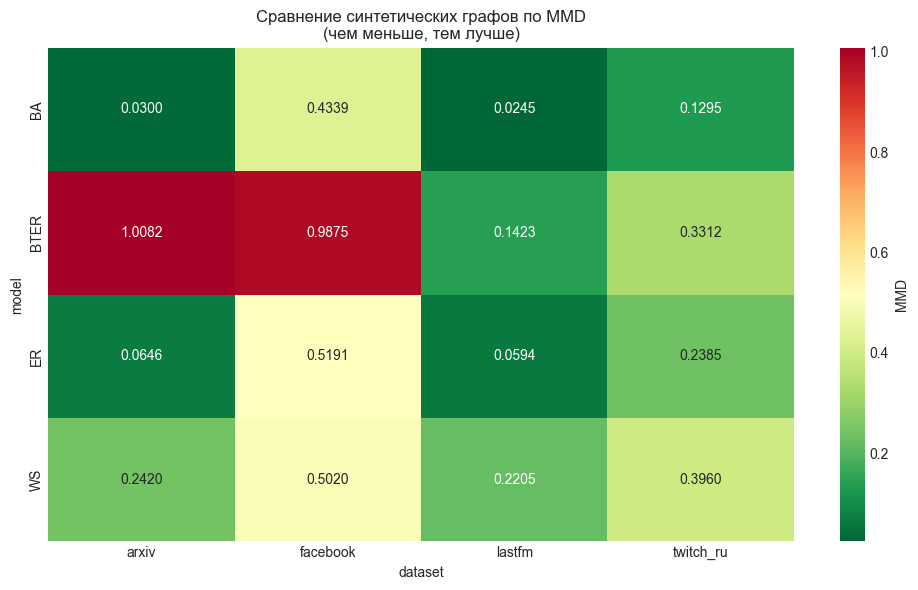

In [27]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_mmd, annot=True, fmt='.4f', cmap='RdYlGn_r', cbar_kws={'label': 'MMD'})
plt.title('Сравнение синтетических графов по MMD\n(чем меньше, тем лучше)')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'figures' / 'mmd_heatmap_all.png', dpi=150, bbox_inches='tight')
plt.show()